In [1]:

!git clone https://github.com/shuvo-iitkgp/heavy-tailed-kmeans.git

%cd heavy-tailed-kmeans

!pip install -r requirements.txt

fatal: destination path 'heavy-tailed-kmeans' already exists and is not an empty directory.
/content/heavy-tailed-kmeans


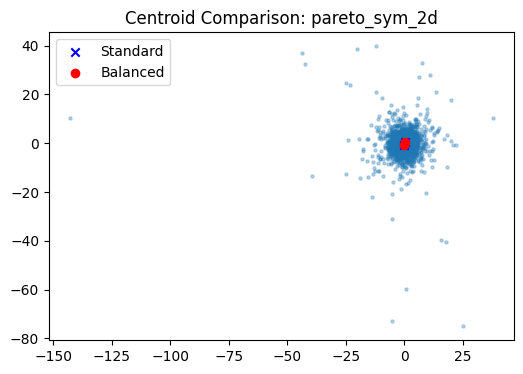

Summary of Distortion and Cluster Sizes:\n
Dataset: pareto_sym
  Distortion - Standard: 0.6186, Balanced: 0.6186
  Cluster Sizes - Standard: {np.int32(0): np.int64(50168), np.int32(1): np.int64(49832)}, Balanced: {np.int32(0): np.int64(50168), np.int32(1): np.int64(49832)}
-
Dataset: pareto_asym
  Distortion - Standard: 0.6310, Balanced: 1845.7379
  Cluster Sizes - Standard: {np.int32(0): np.int64(99999), np.int32(1): np.int64(1)}, Balanced: {np.int32(0): np.int64(95000), np.int32(1): np.int64(5000)}
-
Dataset: mixture_rvs
  Distortion - Standard: 0.6266, Balanced: 0.6266
  Cluster Sizes - Standard: {np.int32(0): np.int64(55087), np.int32(1): np.int64(44913)}, Balanced: {np.int32(0): np.int64(55087), np.int32(1): np.int64(44913)}
-
Dataset: high_dim_pareto
  Distortion - Standard: 48.9900, Balanced: 679.1806
  Cluster Sizes - Standard: {np.int32(0): np.int64(99992), np.int32(1): np.int64(8)}, Balanced: {np.int32(0): np.int64(95000), np.int32(1): np.int64(5000)}
-
Dataset: pareto_sym_2d

In [17]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Utility Functions
def load_synthetic_data():
    datasets = {
        "pareto_sym": np.load("data/raw/pareto_sym_100_000.npy"),
        "pareto_asym": np.load("data/raw/pareto_asym_100_000.npy"),
        "mixture_rvs": np.load("data/raw/miture_rvs_100_000.npy"),
        "high_dim_pareto": np.load("data/raw/high_dim_pareto_100_000.npy"),
        "pareto_sym_2d": np.load("data/raw/pareto_sym_2d_100_000.npy")
    }
    return datasets


def load_nyc_taxi():
    # Load parquet file
    df = pd.read_parquet("data/raw/green_tripdata_2025-08.parquet")

    # Select relevant columns
    cols = ["fare_amount", "trip_distance", "tip_amount", "total_amount"]
    df = df[cols]

    # Remove rows with negative values (log transform cannot handle negatives)
    df = df[(df >= 0).all(axis=1)]

    # Apply log1p transform
    for col in cols:
        df[col] = np.log1p(df[col])

    # Drop any remaining NaNs
    df = df.dropna()

    # Scale the cleaned data
    scaler = StandardScaler()
    return scaler.fit_transform(df)


# Algorithms
def standard_kmeans(X, k):
    model = KMeans(n_clusters=k, random_state=42).fit(X)
    return model.labels_, model.cluster_centers_

def balanced_kmeans(X, k, gamma):
    labels, centers = standard_kmeans(X, k)
    n = len(X)
    min_size = int(gamma * n)
    for cluster_id in range(k):
        cluster_points = np.where(labels == cluster_id)[0]
        if len(cluster_points) < min_size:
            largest_cluster = np.argmax([np.sum(labels==i) for i in range(k)])
            excess = len(cluster_points) - min_size
            if excess < 0:
                move_count = abs(excess)
                candidates = np.where(labels == largest_cluster)[0][:move_count]
                labels[candidates] = cluster_id
    return labels, centers

def trimmed_kmeans(X, k, alpha=0.05):
    n = len(X)
    trim_count = int(alpha * n)
    model = KMeans(n_clusters=k, random_state=42).fit(X)
    labels = model.labels_
    centers = model.cluster_centers_
    dists = np.array([np.linalg.norm(X[i]-centers[labels[i]]) for i in range(n)])
    keep_idx = np.argsort(dists)[:-trim_count]
    return labels[keep_idx], centers

def soft_trimmed_kmeans(X, k, alpha=0.05):
    weights = np.ones(len(X))
    for _ in range(5):
        model = KMeans(n_clusters=k, random_state=42).fit(X, sample_weight=weights)
        labels = model.labels_
        centers = model.cluster_centers_
        dists = np.array([np.linalg.norm(X[i]-centers[labels[i]]) for i in range(len(X))])
        threshold = np.percentile(dists, 100*(1-alpha))
        weights = np.where(dists > threshold, 0.5, 1.0)
    return labels, centers

# Metrics
def distortion(X, labels, centers):
    return np.sum([np.linalg.norm(X[i]-centers[labels[i]])**2 for i in range(len(X))]) / len(X)

def cluster_size_ratios(labels):
    unique, counts = np.unique(labels, return_counts=True)
    return dict(zip(unique, counts))

# Visualization for Synthetic Data
def plot_centroid_convergence(X, centers_std, centers_bal, title):
    plt.figure(figsize=(6, 4))
    plt.scatter(X[:, 0], X[:, 1], s=5, alpha=0.3)
    plt.scatter(centers_std[:, 0], centers_std[:, 1], c='blue', marker='x', label='Standard')
    plt.scatter(centers_bal[:, 0], centers_bal[:, 1], c='red', marker='o', label='Balanced')
    plt.title(f"Centroid Comparison: {title}")
    plt.legend()
    plt.show()

# Run Experiments
synthetic_data = load_synthetic_data()
nyc_data = load_nyc_taxi()

results = []

# Synthetic datasets
for name, X in synthetic_data.items():
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    X_scaled = StandardScaler().fit_transform(X)
    k = 2
    labels_std, centers_std = standard_kmeans(X_scaled, k)
    labels_bal, centers_bal = balanced_kmeans(X_scaled, k, gamma=0.05)
    labels_trim, centers_trim = trimmed_kmeans(X_scaled, k)
    labels_soft, centers_soft = soft_trimmed_kmeans(X_scaled, k)
    results.append({
        "dataset": name,
        "distortion_std": distortion(X_scaled, labels_std, centers_std),
        "distortion_bal": distortion(X_scaled, labels_bal, centers_bal),
        "size_ratio_std": cluster_size_ratios(labels_std),
        "size_ratio_bal": cluster_size_ratios(labels_bal)
    })
    if X_scaled.shape[1] == 2:
        plot_centroid_convergence(X_scaled, centers_std, centers_bal, name)

# NYC Taxi for k=2 and k=3
for k in [2, 3]:
    labels_std, centers_std = standard_kmeans(nyc_data, k)
    labels_bal, centers_bal = balanced_kmeans(nyc_data, k, gamma=0.05)
    labels_trim, centers_trim = trimmed_kmeans(nyc_data, k)
    labels_soft, centers_soft = soft_trimmed_kmeans(nyc_data, k)
    results.append({
        "dataset": f"NYC_Taxi_k{k}",
        "distortion_std": distortion(nyc_data, labels_std, centers_std),
        "distortion_bal": distortion(nyc_data, labels_bal, centers_bal),
        "size_ratio_std": cluster_size_ratios(labels_std),
        "size_ratio_bal": cluster_size_ratios(labels_bal)
    })

# Print summary
print("Summary of Distortion and Cluster Sizes:\\n")
for r in results:
    print(f"Dataset: {r['dataset']}")
    print(f"  Distortion - Standard: {r['distortion_std']:.4f}, Balanced: {r['distortion_bal']:.4f}")
    print(f"  Cluster Sizes - Standard: {r['size_ratio_std']}, Balanced: {r['size_ratio_bal']}")
    print("-")

# Convert results list of dicts to DataFrame
df_results = pd.DataFrame(results)

# Save to CSV
output_path = "results/experiment_0_results.csv"
df_results.to_csv(output_path, index=False)

# Print preview
print("\nClustering Results Summary:")
print(df_results.head())
print(f"\nResults saved to: {output_path}")


